In [12]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
import statsmodels.api as sm
from functions_fcsuml import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)



In [13]:
blobs, labels, centers = datasets.make_blobs(n_samples=90000, n_features=100, centers=20, random_state=42, return_centers=True)

targets = blobs[:, -1]
data = blobs[:, :-1]
print(data.shape, targets.shape)

(90000, 99) (90000,)


In [14]:
training_data, testing_data, training_targets, testing_targets = train_test_split(data, targets, test_size=0.2, random_state=42)

testing_data, validation_data, testing_targets, validation_targets = train_test_split(testing_data, testing_targets, test_size=0.5, random_state=42)

print('X1 shape: ', training_data.shape)
print('X2 shape: ', testing_data.shape)
print('X3 shape: ', validation_data.shape)
print('X4 shape: ', training_targets.shape)
print('X5 shape: ', testing_targets.shape)
print('X6 shape: ', validation_targets.shape)

# Normalizing the data
norm_data, normalization_variables = normalize(training_data)
norm_targets, max_targets, min_targets = normalize_feature(training_targets)

norm_testing_targets = (testing_targets-min_targets)/(max_targets-min_targets)
norm_validation_targets = (validation_targets-min_targets)/(max_targets-min_targets)
norm_validation_data = (validation_data-normalization_variables[1])/(normalization_variables[0]-normalization_variables[1])
norm_testing_data = (testing_data-normalization_variables[1])/(normalization_variables[0]-normalization_variables[1])
print(np.shape(norm_data))

X1 shape:  (72000, 99)
X2 shape:  (9000, 99)
X3 shape:  (9000, 99)
X4 shape:  (72000,)
X5 shape:  (9000,)
X6 shape:  (9000,)
(72000, 99)


# Raw data

In [15]:
X_norm_data = sm.add_constant(norm_data)

model_sm = sm.OLS(norm_targets, X_norm_data)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 2.395e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:52:27   Log-Likelihood:             1.2338e+05
No. Observations:               72000   AIC:                        -2.466e+05
Df Residuals:                   71900   BIC:                        -2.456e+05
Df Model:                          99                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4978      0.018     28.256      0.0

# Embedded data

[    0.     0.  3598.  7214. 10814. 14428. 18058. 21636. 25229. 28862.
 32457. 36012. 39640. 43219. 46839. 50411. 54033. 57609. 61194. 64801.
 68406. 72000.]
avg sil: 0.8099443777432098 
 cluster silhouettes: 
 [[ 1.          0.8193972 ]
 [ 2.          0.81625677]
 [ 3.          0.81517759]
 [ 4.          0.8059251 ]
 [ 5.          0.80561717]
 [ 6.          0.81306206]
 [ 7.          0.81107104]
 [ 8.          0.81118867]
 [ 9.          0.81291509]
 [10.          0.81283613]
 [11.          0.81281771]
 [12.          0.81234477]
 [13.          0.80858259]
 [14.          0.80321447]
 [15.          0.80319217]
 [16.          0.80876301]
 [17.          0.80548143]
 [18.          0.80571445]
 [19.          0.8066089 ]
 [20.          0.80877282]] 
 argmax 0


/Users/davidbaaw/code/Exjobb/functions_fcsuml.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


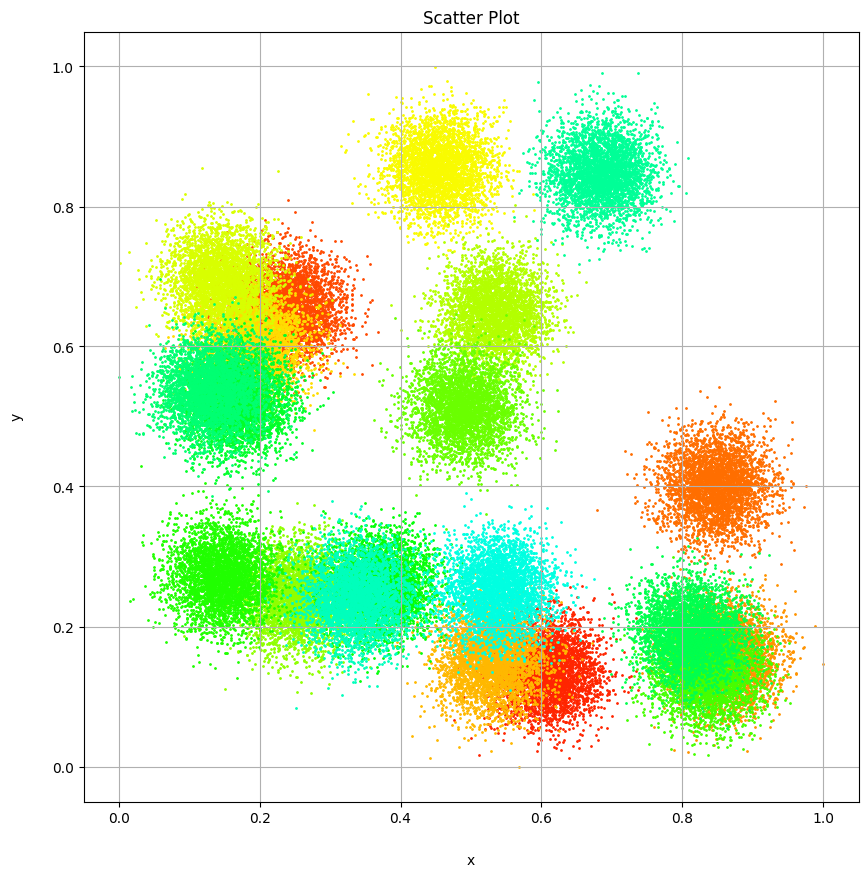

In [16]:
number_of_clusters, optimal_clustering = clustering(norm_data, cluster_size=100, min_samples=2)

sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:, 0] += 1
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [17]:
def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector

def center_of_mass(number_of_clusters, clusters):

    cluster_centers = np.zeros((number_of_clusters, np.shape(clusters)[1]))
    # print(cluster_centers.shape)
    # print(clusters[np.where(clusters[:,0] == 1)])
    # balancing_vector = np.zeros_like
    for i in range(1, number_of_clusters+1):
        cluster_x = clusters[np.where(clusters[:,0] == i)]
        # print(np.shape(cluster_x))
        cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]

    return cluster_centers


def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

centers_of_mass = center_of_mass(number_of_clusters, sorted_clusters)
print(centers_of_mass)
transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

# norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
print(np.shape(embedded_data))
# print(norm_embedded_data)

[[ 1.          0.13617109  0.6085524  ...  0.67518292  0.80906928
   0.79573105]
 [ 2.          0.65551654  0.24188323 ...  0.33840248  0.80902749
   0.13284527]
 [ 3.          0.40062921  0.84664919 ...  0.51685777  0.43729203
   0.1422292 ]
 ...
 [18.          0.84833712  0.68481617 ...  0.58967244  0.24986402
   0.39174998]
 [19.          0.24180397  0.33875065 ...  0.33466831  0.56009958
   0.23888449]
 [20.          0.25412707  0.53852725 ...  0.28376616  0.24681978
   0.71556661]]
(72000, 20)


In [18]:
embedded_testing_data = (transformation_matrix@norm_testing_data.T).T
X_embedded_data = sm.add_constant(embedded_data)

model_sm = sm.OLS(norm_targets, X_embedded_data)
results_sm = model_sm.fit()

print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                 1.183e+05
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:37:44   Log-Likelihood:             1.2328e+05
No. Observations:               72000   AIC:                        -2.465e+05
Df Residuals:                   71979   BIC:                        -2.463e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4944      0.017     28.283      0.0

# PCA

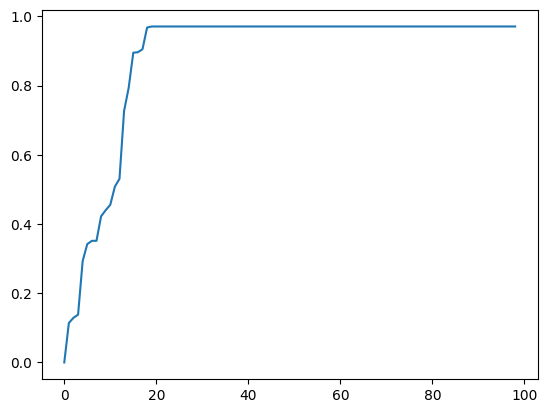

In [19]:
max_n_components = norm_data.shape[1]
r2_mat = np.zeros(max_n_components)

for n in range(max_n_components):
    pca = PCA(n_components=n)
    pca.fit(norm_data)

    pca_embed = pca.fit_transform(norm_data)
    # print(pca_embed.shape)
    # print(pca.explained_variance_ratio_)
    # print(pca.singular_values_)
    

    pca_embedded_data = sm.add_constant(pca_embed)

    pca_model_sm = sm.OLS(norm_targets, pca_embedded_data)
    pca_results_sm = pca_model_sm.fit()
    r2_mat[n] = pca_results_sm.rsquared_adj

plt.plot(r2_mat)


In [20]:
pca = PCA(n_components=20)
pca.fit(norm_data)

pca_embed = pca.fit_transform(norm_data)
print(pca_embed.shape)
# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)


pca_embedded_data = sm.add_constant(pca_embed)

pca_model_sm = sm.OLS(norm_targets, pca_embedded_data)
pca_results_sm = pca_model_sm.fit()

print(pca_results_sm.summary())

(72000, 20)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                 1.184e+05
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:38:55   Log-Likelihood:             1.2329e+05
No. Observations:               72000   AIC:                        -2.465e+05
Df Residuals:                   71979   BIC:                        -2.463e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4928      0.000   3027.